In [1]:
from pathlib import Path
from typing import Dict, List, Tuple
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import xarray as xr

from model_tuner.opt.regimes import (
    NetRegimeWC, NetRegimeWCList,
    NetRegime1DList
)
from model_tuner.opt.ir_mappers import NetIRMapperWC
from model_tuner.opt.uc_mappers import NetUCMapper1D
from model_tuner.opt.wc import ModelDescWC
from model_tuner.opt.wc import wc_gain, run_wc_model

from model_tuner.main import (
    UCMapFitParams,
    init_uc_mapper,
    plot_opt_iteration_pop
)

from model_tuner.utils import load_yaml

from uc_optimizer import OptStrategy, OptStrategyParams, UCOptimizer

warnings.filterwarnings('ignore')


def load_uc_map_params() -> UCMapFitParams:
    """Load UC map params. """
    dirpath_base = Path(
        r'D:\WORK\Salvador\repo\model_tuner\test_data\main'
        r'\test_opt_A1_hpc_batch_qsub\experiments'
        r'\test_2_pfr=(0.4_1.0_4)_wmult=0.005_alpha=1'
    )
    uc_map_params: UCMapFitParams = load_yaml(
        dirpath_base / 'uc_map_params.yaml',
        data_class=UCMapFitParams
    )
    return uc_map_params

def create_wc_model(
        npops: int,
        nifrac: float = 0.5,   # fraction of inhibitory pops.
        g: float = 1,   # global weight multiplier
        gi: float = 1   # additional inhibitory weight multiplier
        ) -> ModelDescWC:

    npops_i = int(npops * nifrac)

    W = np.random.randn(npops, npops)
    W = np.abs(W) * g
    W[:, -npops_i:] *= -gi

    model = ModelDescWC.create_unconn(num_pops=npops)
    model.conn = W
    
    return model

def plot_rc_data(
        Rc_data: xr.DataArray,   # (pop x pfr x iter)
        rr_base: List[float] | np.ndarray,   # (pop x 1)
        pops_vis: List[str] | None = None,
        show_xlabel: bool = True,
        show_ylabel: bool = True
        ) -> None:

    pop_names = Rc_data.pop.values
    pfr_vec = Rc_data.pfr.values
    niter = Rc_data.iter.size

    if not pops_vis:
        pops_vis = pop_names
    npops_vis = len(pops_vis)
    
    rr_base = [rr_base[list(pop_names).index(pop)] for pop in pops_vis]

    for pop_num, pop in enumerate(pops_vis):
        #plt.subplot(1, npops_vis, pop_num + 1)
        for pfr in pfr_vec:
            rc_vec = Rc_data.sel(pop=pop, pfr=pfr).values
            plt.plot(rc_vec, label=f'pfr={pfr:.02f}')
        plt.plot([0, niter], [rr_base[pop_num]] * 2, 'k--')
        #plt.legend()
        if show_xlabel:
            plt.xlabel('Iteration')
        if show_ylabel:
            plt.ylabel('Rc')
        plt.title(pop)

def run_opt_experiment(
        model: ModelDescWC,
        uc_optimizer: UCOptimizer,
        sim_par: Dict,
        verbose=False
        ) -> None:
    
    uc_optimizer.begin()
    
    for iter_num in tqdm(range(1, uc_optimizer.n_iter)):
        if verbose:
            print(f'Iter: {iter_num}')

        # Rc0 -> Ru
        Ru_lst = uc_optimizer.suggest_Ru()
        NetRegimeWCList._convert_parent(Ru_lst)

        # Run the model for each pfr value
        Rc_lst = NetRegimeWCList()
        for n, Ru in enumerate(Ru_lst):
            # Ru -> Iu
            Iu = ir_mapper.R_to_I(Ru)
            # Run model with Iu and get the resulting Rc
            Rc, sim_info = run_wc_model(
                model, Iu, sim_par['niter'], Ru, sim_par['dr_mult']
            )
            Rc_lst.append(Rc)
        
        # Store Ru and Rc
        uc_optimizer.store_sim_result(Ru_lst, Rc_lst)
        
        # Fit UC mapping
        uc_optimizer.fit_uc_mapper()

        # Proceed to the next iteration
        uc_optimizer.next_iter()

c:\Users\aleks\.conda\envs\netpyne_batch\lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,


100%|██████████| 49/49 [00:03<00:00, 15.91it/s]


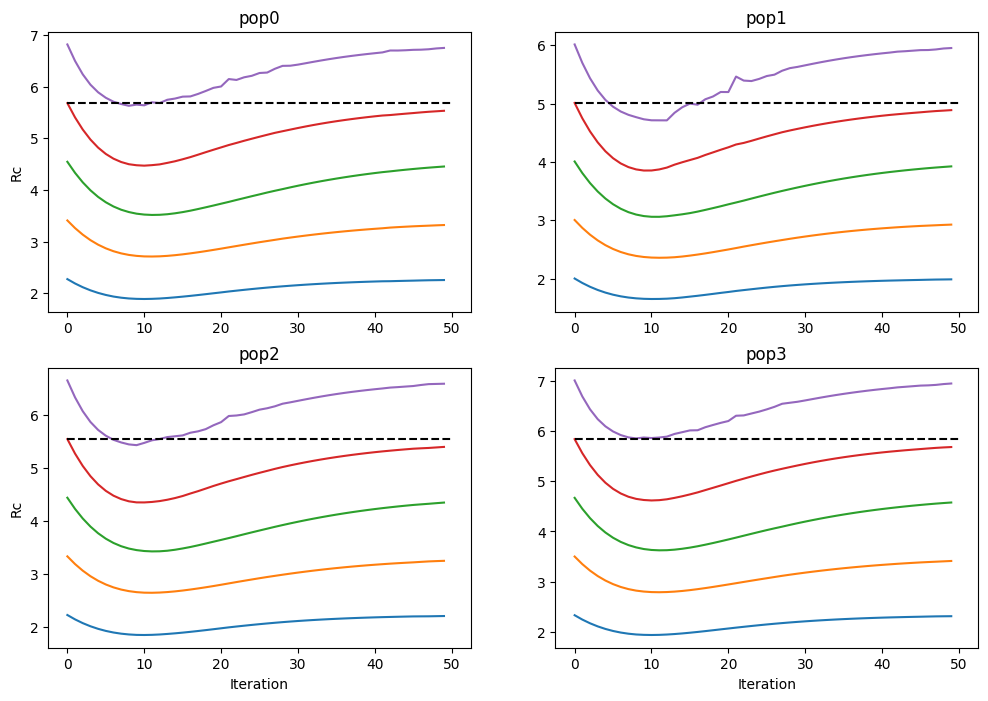

In [2]:

# Problematic:
#np.random.seed(115|116) - doesn't converge
#np.random.seed(114) - oscillations with alpha=1, autosz
#model = create_wc_model(npops=4, g=0.2)

np.random.seed(115)

# WC model
model = create_wc_model(npops=4, g=0.2)

# Original target rate vector
rmin, rmax = 1, 6
rr_base = rmin + (rmax - rmin) * np.random.rand(model.npops)

# Target regime multipliers
pfr_vec = np.array([0.4, 0.6, 0.8, 1, 1.2])

# Parameters of WC "simulation"
sim_par = {'niter': 20, 'dr_mult': 1}

# UC map params
uc_map_params = load_uc_map_params()
uc_map_params.pop_names = model.get_pop_names()

# Numbr of iterations
n_iter = 50

# Optimization strategy
opt_strategy = OptStrategy.STEP_TO_NEW
#opt_strategy = OptStrategy.STEP_TO_NEW_AUTOSZ
#opt_strategy = OptStrategy.STEP_TO_NEW_ROT
opt_strategy_par = OptStrategyParams(
    alpha=0.1,
    alpha_Ru=0.1,
    alpha_mult=0.8,
    alpha_min=0.01,
    dmax_rot=0.5
)

# I-R mapper, explicitly uses WC gain functions
ir_mapper = NetIRMapperWC(model)

# Initialize UC optimizer
uc_optimizer = UCOptimizer(
    uc_map_params, model.get_pop_names(), rr_base, pfr_vec,
    n_iter, opt_strategy, opt_strategy_par
)

# Main simulation-optimmization loop
try:
    run_opt_experiment(model, uc_optimizer, sim_par, verbose=0)
except Exception as e:
    print(e)

# Plot the result
#plt.ion()
plt.figure(figsize=(12, 8))
for n in range(4):
    plt.subplot(2, 2, n + 1)
    plot_rc_data(uc_optimizer.step_data['Rc'], rr_base,
                 pops_vis=[f'pop{n}'],
                 show_xlabel=(n in (2, 3)),
                 show_ylabel=(n in (0, 2))
                 )
#plt.show()


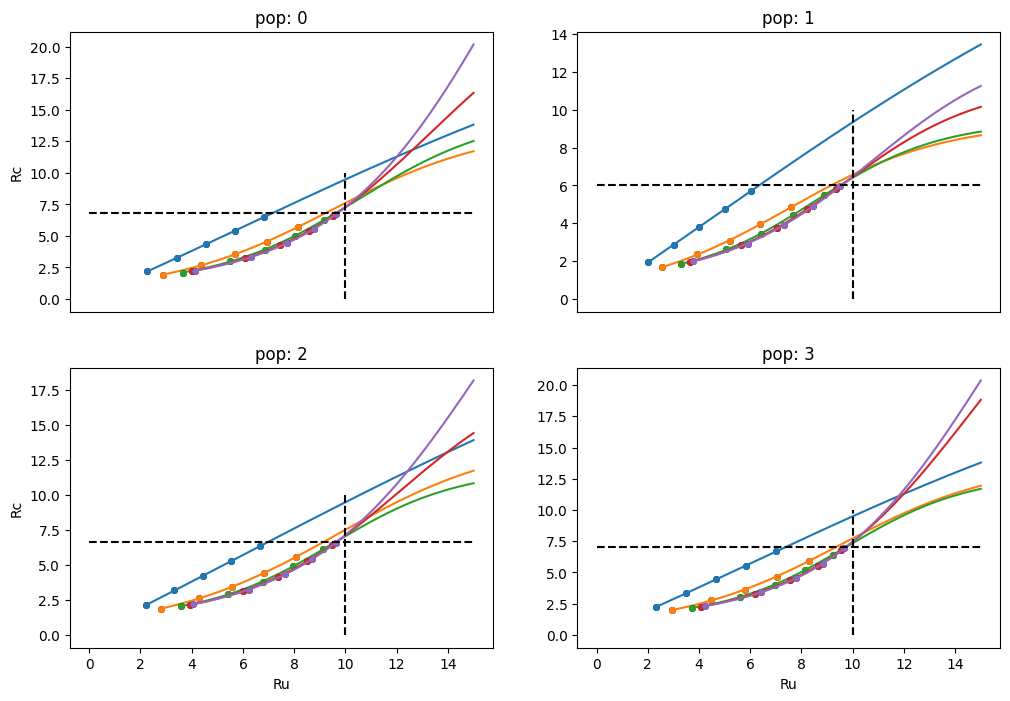

In [3]:
Rc = uc_optimizer.step_data['Rc']
Ru = uc_optimizer.step_data['Ru']

nx, ny = 2, 2
iters_vis = np.linspace(1, uc_optimizer.n_iter - 1,
                        num=5, dtype=int)

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.figure(figsize=(12, 8))

for pop in range(4):
    plt.subplot(nx, ny, pop + 1)

    for color_num, iter in enumerate(iters_vis):
        plot_opt_iteration_pop(
            pop_names=uc_optimizer.pop_names,
            pop_name_vis=uc_optimizer.pop_names[pop],
            uc_mapper=uc_optimizer.uc_mappers[iter],
            Ru_lst=NetRegime1DList.from_xr(Ru.isel(iter=iter)), 
            Rc_lst=NetRegime1DList.from_xr(Rc.isel(iter=iter)), 
            ru_limits=(0, 15),
            color=colors[color_num % len(colors)]
        )
        cc = {'pop': pop, 'iter': iter}
        plt.plot(Ru.isel(**cc), Rc.isel(**cc), '.', markersize=8)
    
    plt.plot([10, 10], [0, 10], 'k--')
    plt.plot([0, 15], [uc_optimizer.Rc0.isel(pop=pop, pfr=-1)] * 2, 'k--')

    if pop in [2, 3]:
        plt.xlabel('Ru')
    else:
        plt.xlabel('')
        plt.xticks([])

    if pop in [0, 2]:
        plt.ylabel('Rc')
    else:
        plt.ylabel('')

    plt.title(f'pop: {pop}')

In [4]:
np.linspace(1, uc_optimizer.n_iter - 1, 5, dtype=int)

array([ 1, 13, 25, 37, 49])